In [1]:
from IPython.display import display
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

sns.set_theme(style="whitegrid")


In [2]:
df = pd.read_csv('diabetes.csv').copy()
target_col = 'Outcome'
feature_cols = df.columns.drop(target_col)
numeric_cols = df[feature_cols].select_dtypes(include=np.number).columns
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [4]:
df["Outcome"].value_counts


<bound method IndexOpsMixin.value_counts of 0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64>

df.isnull().sum()

In [5]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [6]:
df.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [7]:
for col in df.columns:
    if col != "Outcome":
        df[col] = pd.to_numeric(df[col], errors='coerce')

In [8]:
for col in df.columns:
    if col != "Outcome":
        df[col] = df[col].replace(0, np.nan)

In [9]:
for col in df.columns:
    if col != "Outcome":
        df[col].fillna(df[col].median(),inplace=True)

C:\Users\harsh\AppData\Local\Temp\ipykernel_14020\831314375.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(),inplace=True)


In [10]:
df.head

<bound method NDFrame.head of      Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6.0    148.0           72.0           35.0    125.0  33.6   
1            1.0     85.0           66.0           29.0    125.0  26.6   
2            8.0    183.0           64.0           29.0    125.0  23.3   
3            1.0     89.0           66.0           23.0     94.0  28.1   
4            4.0    137.0           40.0           35.0    168.0  43.1   
..           ...      ...            ...            ...      ...   ...   
763         10.0    101.0           76.0           48.0    180.0  32.9   
764          2.0    122.0           70.0           27.0    125.0  36.8   
765          5.0    121.0           72.0           23.0    112.0  26.2   
766          1.0    126.0           60.0           29.0    125.0  30.1   
767          1.0     93.0           70.0           31.0    125.0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
0                       0.627   50 

In [11]:

X = df.drop('Outcome', axis=1)
y = df['Outcome']


In [12]:
#scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [13]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

print(X.shape)
print(X_pca.shape)

(768, 8)
(768, 7)


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42, stratify=y
)

In [15]:
print(f'Shape: {df.shape}')
print()
print('First 5 rows')
display(df.head())

print('Data Types')
display(df.dtypes.rename('dtype').to_frame())

print('Summary Statistics')
display(df.describe(include='all').T)

print(f'Duplicate rows: {df.duplicated().sum()}')


Shape: (768, 9)

First 5 rows


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6.0,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1.0,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8.0,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,4.0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


Data Types


,dtype
Pregnancies,float64
Glucose,float64
BloodPressure,float64
SkinThickness,float64
Insulin,float64
BMI,float64
DiabetesPedigreeFunction,float64
Age,int64
Outcome,int64


Summary Statistics


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,4.423177,2.980481,1.000,2.00000,4.0000,6.00000,17.00
Glucose,768.0,121.656250,30.438286,44.000,99.75000,117.0000,140.25000,199.00
BloodPressure,768.0,72.386719,12.096642,24.000,64.00000,72.0000,80.00000,122.00
SkinThickness,768.0,29.108073,8.791221,7.000,25.00000,29.0000,32.00000,99.00
Insulin,768.0,140.671875,86.383060,14.000,121.50000,125.0000,127.25000,846.00
BMI,768.0,32.455208,6.875177,18.200,27.50000,32.3000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


Duplicate rows: 0


In [16]:
print(df.isna().sum())


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [17]:
print(df[target_col].value_counts())


Outcome
0    500
1    268
Name: count, dtype: int64


In [18]:
print((df[numeric_cols] == 0).sum())




Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64


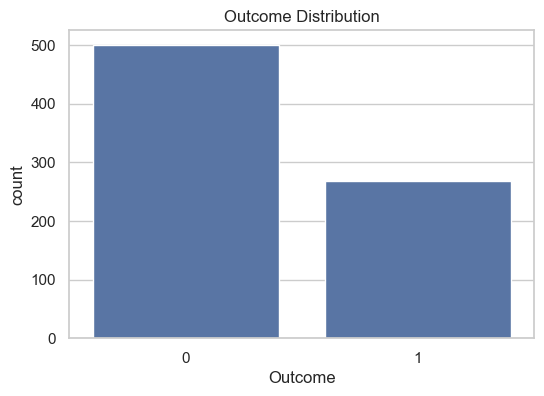

In [19]:
plt.figure(figsize=(6,4))
sns.countplot(x=target_col, data=df)
plt.title("Outcome Distribution")
plt.show()

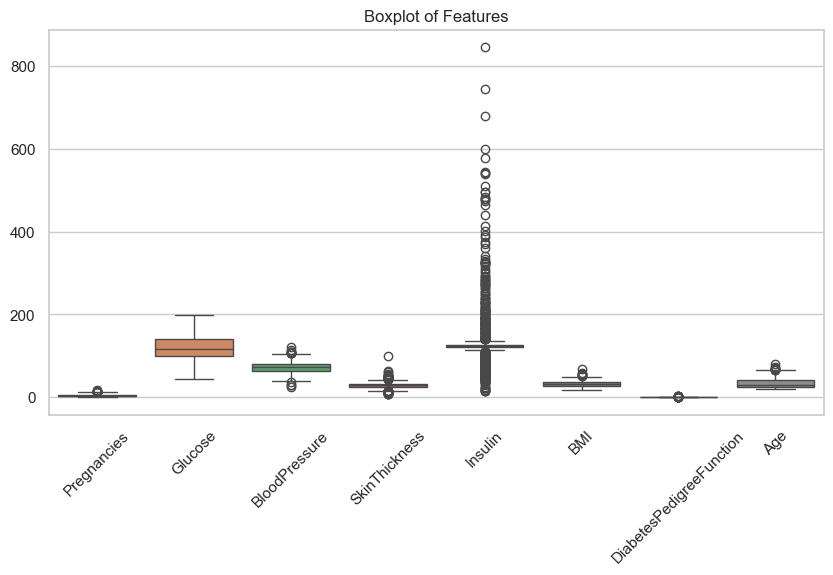

In [20]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df[numeric_cols])
plt.xticks(rotation=45)
plt.title("Boxplot of Features")
plt.show()

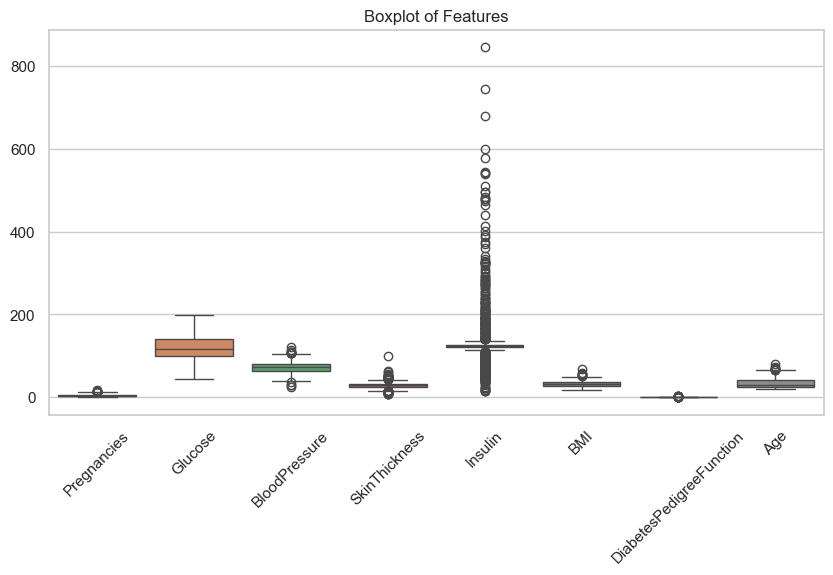

In [21]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df[numeric_cols])
plt.xticks(rotation=45)
plt.title("Boxplot of Features")
plt.show()

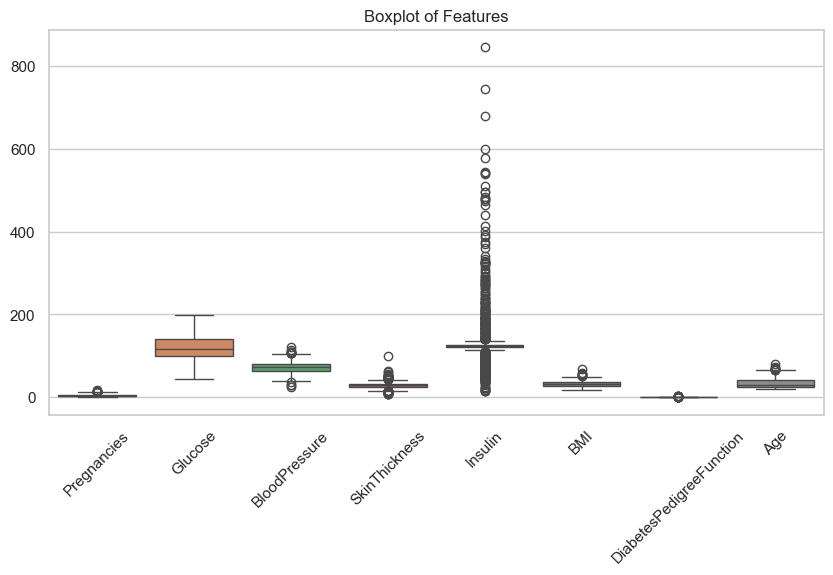

In [22]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df[numeric_cols])
plt.xticks(rotation=45)
plt.title("Boxplot of Features")
plt.show()

In [23]:

# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# PCA
pca = PCA(n_components=0.95)

X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

In [24]:
Logistic_param = {'C': [0.01, 0.1, 1, 10]}
model_logistic = LogisticRegression(max_iter=1000, random_state=42)

KNN_param = {'n_neighbors': [3, 5, 7, 9]}
model_knn = KNeighborsClassifier()

SVM_param = {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}
model_svm = SVC(random_state=42)

Tree_param = {'max_depth': [3, 5, 10], 'min_samples_split': [2, 5]}
model_tree = DecisionTreeClassifier(random_state=42)

RF_param = {'n_estimators': [50, 100], 'max_depth': [3, 5, 10]}
model_rf = RandomForestClassifier(random_state=42)

grid_log = GridSearchCV(model_logistic, Logistic_param, cv=5, n_jobs=-1)
grid_log.fit(X_train, y_train)

grid_knn = GridSearchCV(model_knn, KNN_param, cv=5, n_jobs=-1)
grid_knn.fit(X_train, y_train)

grid_svm = GridSearchCV(model_svm, SVM_param, cv=5, n_jobs=-1)
grid_svm.fit(X_train, y_train)

grid_dt = GridSearchCV(model_tree, Tree_param, cv=5, n_jobs=-1)
grid_dt.fit(X_train, y_train)

grid_rf = GridSearchCV(model_rf, RF_param, cv=5, n_jobs=-1)
grid_rf.fit(X_train, y_train)

models = {
    'Logistic': grid_log.best_estimator_,
    'KNN': grid_knn.best_estimator_,
    'SVM': grid_svm.best_estimator_,
    'Decision Tree': grid_dt.best_estimator_,
    'Random Forest': grid_rf.best_estimator_,
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    print(name, 'Accuracy:', accuracy_score(y_test, y_pred))


Logistic Accuracy: 0.7077922077922078
KNN Accuracy: 0.7337662337662337
SVM Accuracy: 0.7142857142857143
Decision Tree Accuracy: 0.6883116883116883
Random Forest Accuracy: 0.6948051948051948


In [25]:

results = []

models = [
    ('Logistic', grid_log),
    ('KNN', grid_knn),
    ('SVM', grid_svm),
    ('Decision Tree', grid_dt),
    ('Random Forest', grid_rf),
]

for name, grid in models:
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)

    results.append({
        'Model': name,
        'Best Params': grid.best_params_,
        'CV Best Score': round(grid.best_score_, 4),
        'Test Accuracy': round(accuracy_score(y_test, y_pred), 4)
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='Test Accuracy', ascending=False).reset_index(drop=True)

print("Model Comparison")
print(results_df)

print("\nBest model on test data:", results_df.loc[0, 'Model'])
print("Best parameters:", results_df.loc[0, 'Best Params'])

Model Comparison
           Model                               Best Params  CV Best Score  \
0            KNN                        {'n_neighbors': 7}         0.7671   
1            SVM              {'C': 1, 'kernel': 'linear'}         0.7867   
2       Logistic                                  {'C': 1}         0.7834   
3  Random Forest     {'max_depth': 5, 'n_estimators': 100}         0.7753   
4  Decision Tree  {'max_depth': 3, 'min_samples_split': 2}         0.7573   

   Test Accuracy  
0         0.7338  
1         0.7143  
2         0.7078  
3         0.6948  
4         0.6883  

Best model on test data: KNN
Best parameters: {'n_neighbors': 7}
